In [1]:
import pandas as pd
import numpy as np
from matplotlib import pylab as plt
import seaborn as sns
import math

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [3]:
df = pd.read_csv("WineQT.csv")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


## 🍷 Dataset Variables Description

### 🔹 Input Variables (Physicochemical Tests)

**1. Fixed Acidity**  
Represents the concentration of non-volatile (fixed) acids in wine, mainly tartaric acid. These acids contribute to the wine’s structure and stability.

**2. Volatile Acidity**  
Measures the amount of acetic acid in wine. High values may lead to an unpleasant vinegar-like taste and are usually considered a fault.

**3. Citric Acid**  
A weak organic acid that adds freshness and flavor. In small amounts, it can enhance wine balance.

**4. Residual Sugar**  
The amount of sugar remaining after fermentation. Influences sweetness level and mouthfeel.

**5. Chlorides**  
Indicates the salt content in wine. Excessive levels can negatively affect taste.

**6. Free Sulfur Dioxide**  
The portion of sulfur dioxide available to protect wine from microbial growth and oxidation.

**7. Total Sulfur Dioxide**  
Includes both free and bound sulfur dioxide. High levels may cause pungent odors and headaches.

**8. Density**  
Relates to the wine’s mass per unit volume. Often correlated with sugar and alcohol content.

**9. pH**  
Measures acidity or basicity. Lower pH values indicate higher acidity and better microbial stability.

**10. Sulphates**  
Contribute to sulfur dioxide formation and can enhance wine’s flavor and preservation.

**11. Alcohol**  
Percentage of ethanol in wine. Strongly associated with perceived body and quality.

---

### 🔹 Output Variable (Sensory Data)

**12. Quality**  
A score between 0 and 10 assigned by human tasters, reflecting overall wine quality based on sensory evaluation.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [5]:
del df["Id"]
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6


In [6]:
df = df.drop_duplicates().reset_index(drop=True)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1013,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1014,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1015,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1016,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1018 entries, 0 to 1017
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1018 non-null   float64
 1   volatile acidity      1018 non-null   float64
 2   citric acid           1018 non-null   float64
 3   residual sugar        1018 non-null   float64
 4   chlorides             1018 non-null   float64
 5   free sulfur dioxide   1018 non-null   float64
 6   total sulfur dioxide  1018 non-null   float64
 7   density               1018 non-null   float64
 8   pH                    1018 non-null   float64
 9   sulphates             1018 non-null   float64
 10  alcohol               1018 non-null   float64
 11  quality               1018 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 95.6 KB


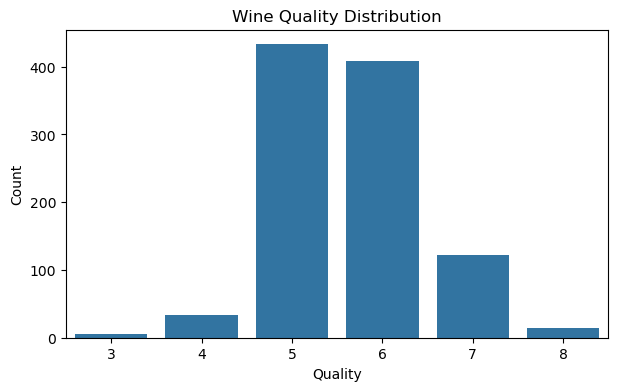

In [8]:
plt.figure(figsize=(7,4))
sns.countplot(x="quality", data=df)
plt.title("Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

In [9]:
df.quality.value_counts()/len(df)

quality
5    0.425344
6    0.401768
7    0.119843
4    0.032417
8    0.014735
3    0.005894
Name: count, dtype: float64

In [10]:
df.loc[df.quality==3, "quality"] = 4
df.loc[df.quality==8, "quality"] = 7 

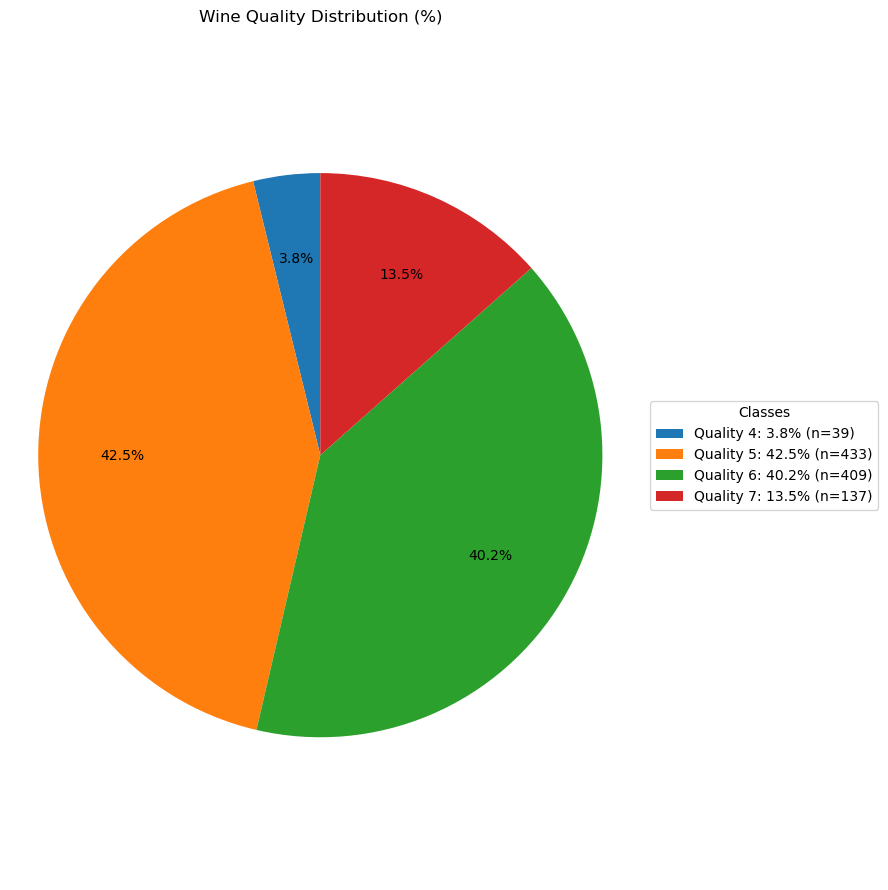

In [11]:
quality_counts = df["quality"].value_counts().sort_index()
percent = quality_counts / quality_counts.sum() * 100

def autopct_big(pct):
    return f"{pct:.1f}%" if pct >= 3 else ""

plt.figure(figsize=(9,9))

wedges, texts, autotexts = plt.pie(
    quality_counts.values,
    labels=None,               
    autopct=autopct_big,      
    startangle=90,
    pctdistance=0.70
)

legend_labels = [f"Quality {q}: {p:.1f}% (n={c})"
                 for q, p, c in zip(quality_counts.index, percent.values, quality_counts.values)]

plt.legend(
    wedges,
    legend_labels,
    title="Classes",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.title("Wine Quality Distribution (%)")
plt.axis("equal")
plt.tight_layout()
plt.show()


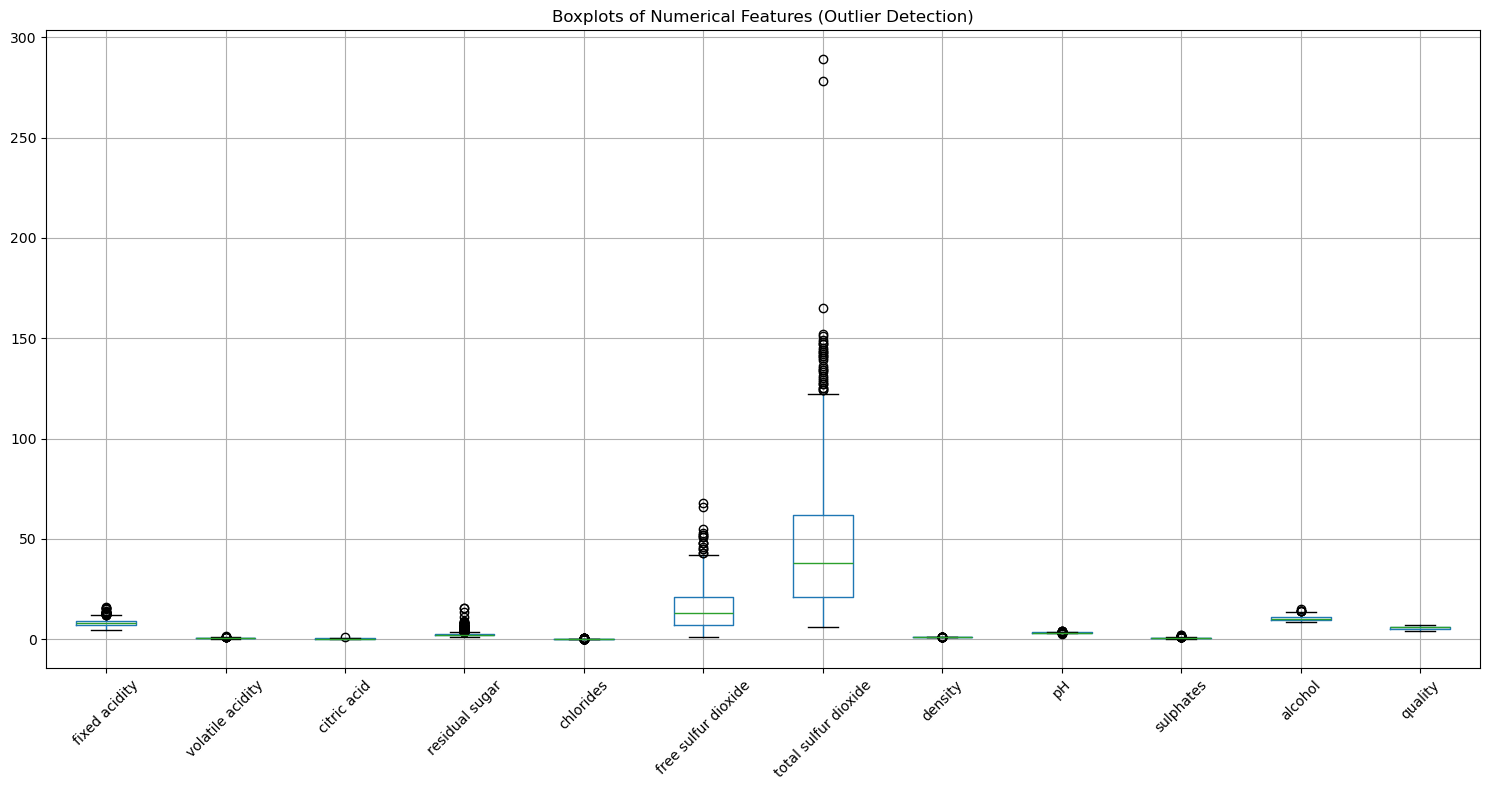

In [12]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(15, 8))
df[num_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features (Outlier Detection)")
plt.tight_layout()
plt.show()

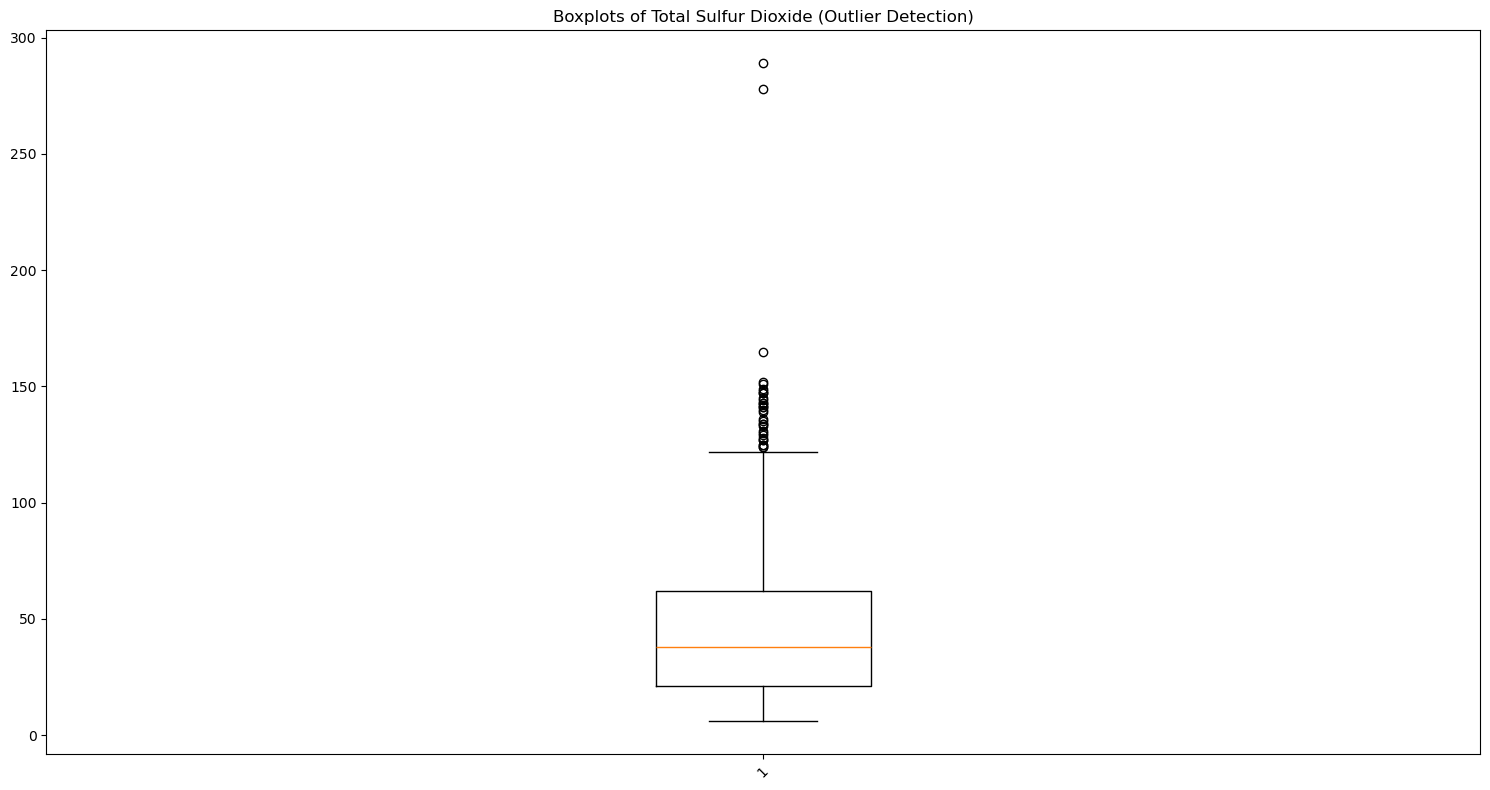

In [13]:
plt.figure(figsize=(15, 8))
plt.boxplot(df["total sulfur dioxide"].values)
plt.xticks(rotation=45)
plt.title("Boxplots of Total Sulfur Dioxide (Outlier Detection)")
plt.tight_layout()
plt.show()

In [14]:
thresholds = {
    "fixed acidity": (3, 15),
    "volatile acidity": (0.1, 1.5),
    "citric acid": (0.0, 1.5),
    "residual sugar": (0.5, 20),
    "chlorides": (0.01, 0.3),
    "free sulfur dioxide": (1, 100),
    "total sulfur dioxide": (5, 200),
    "density": (0.985, 1.005),
    "pH": (2.5, 4.2),
    "sulphates": (0.2, 2.0),
    "alcohol": (8.0, 15.5)
}

In [15]:
df_clean = df.copy()

for col, (low, high) in thresholds.items():
    df_clean = df_clean[
        (df_clean[col] >= low) &
        (df_clean[col] <= high)
    ]

print("Original size:", df.shape)
print("Cleaned size:", df_clean.shape)

Original size: (1018, 12)
Cleaned size: (997, 12)


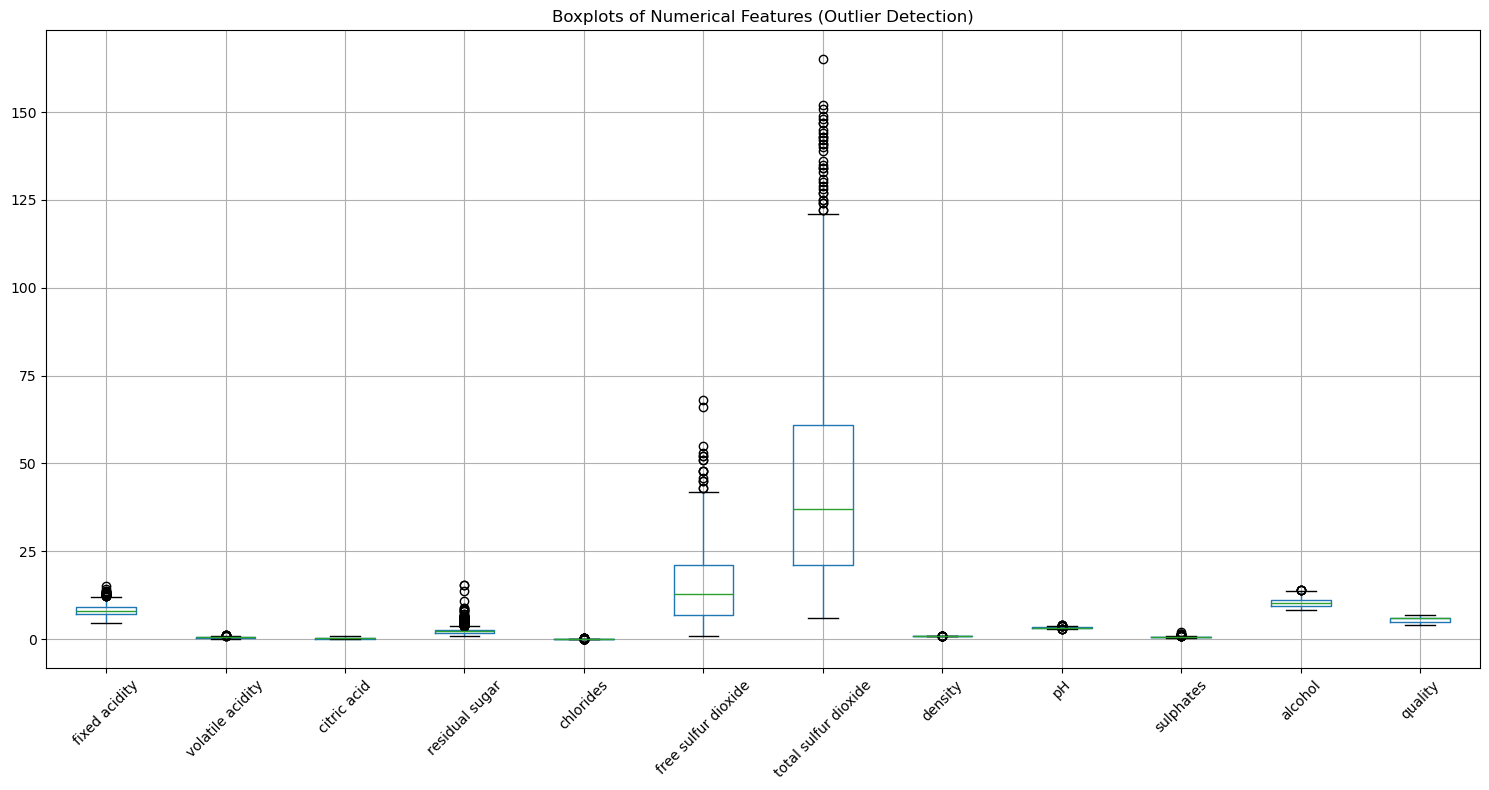

In [16]:
num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(15, 8))
df_clean[num_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features (Outlier Detection)")
plt.tight_layout()
plt.show()

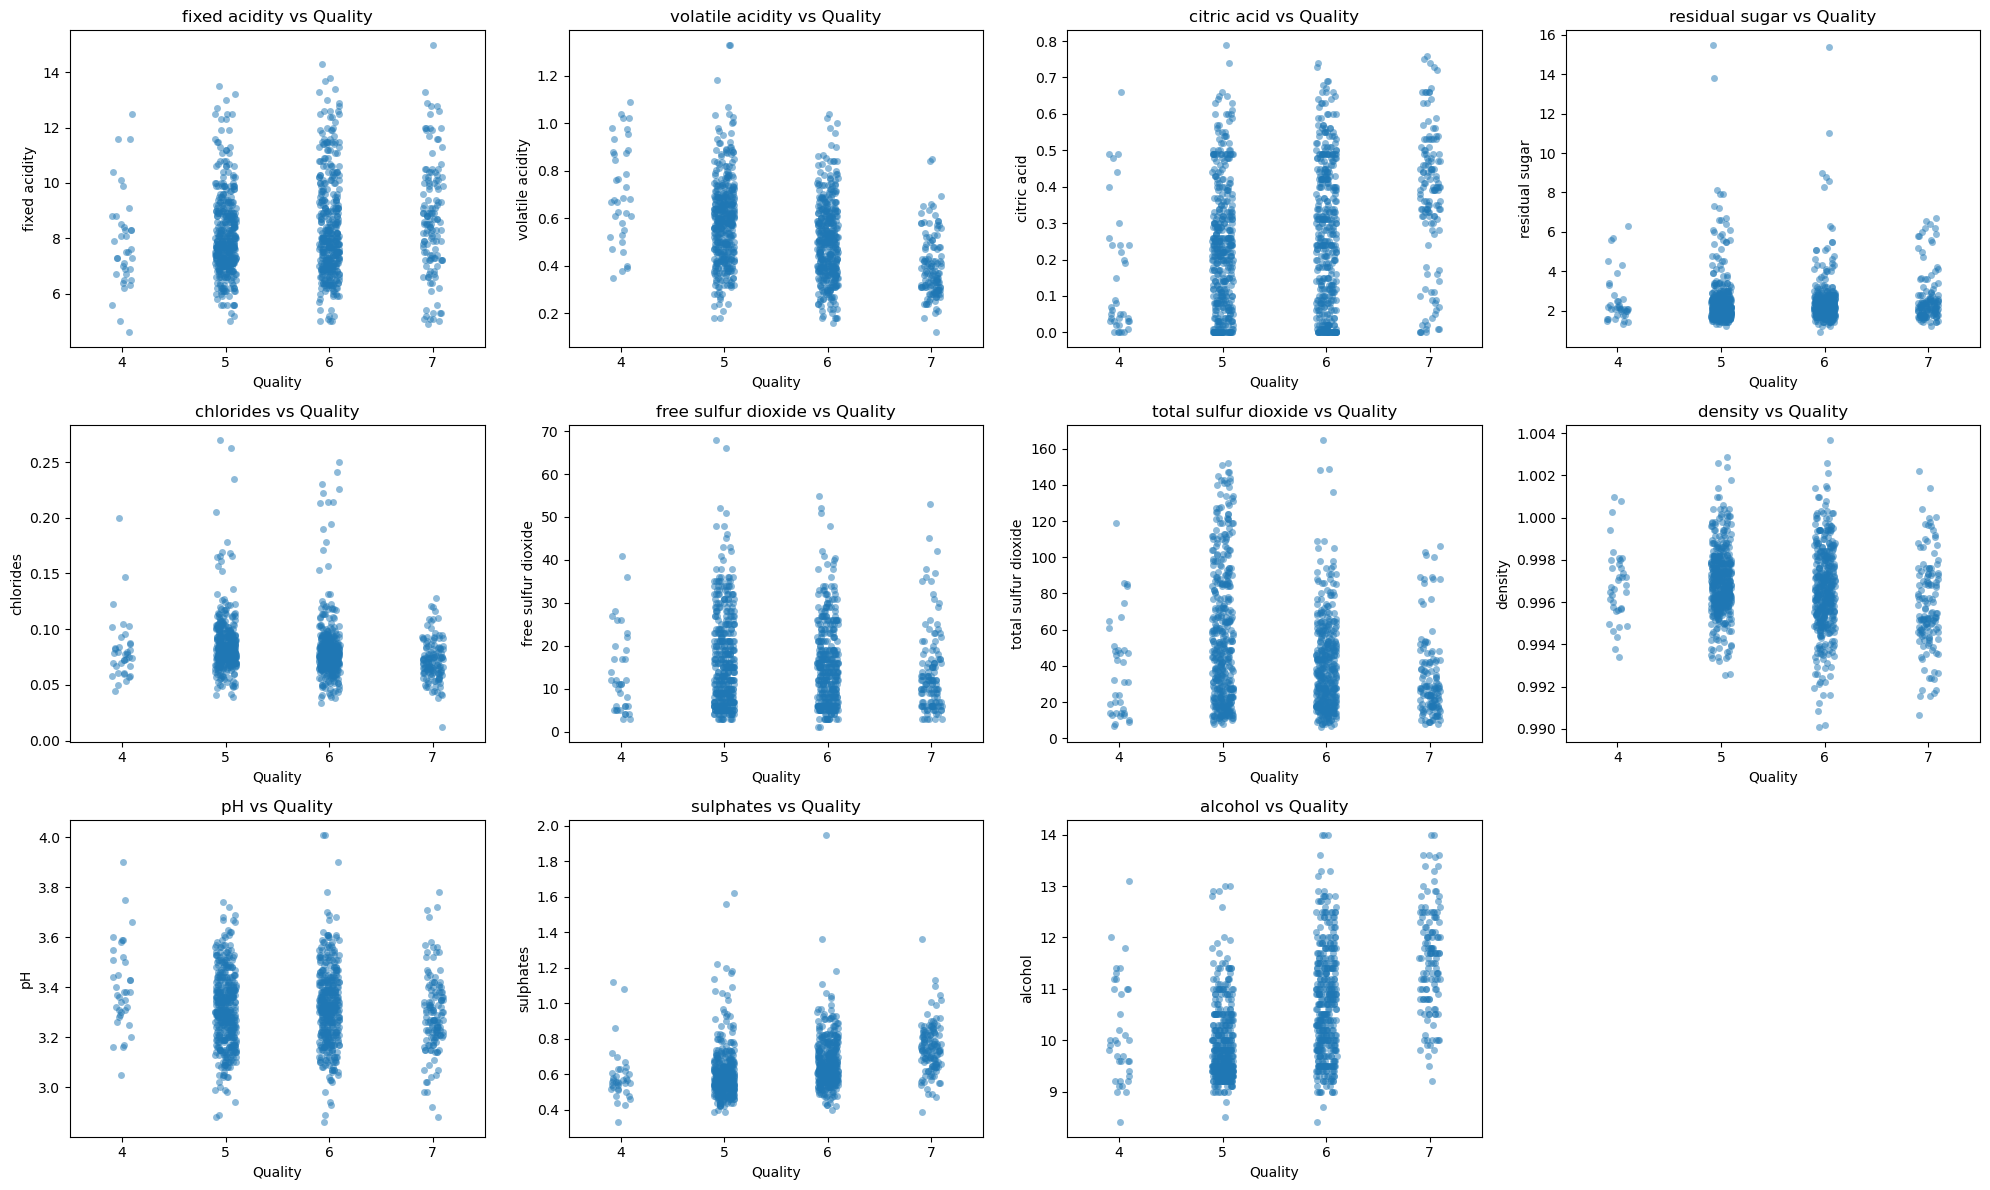

In [17]:
features = [c for c in df_clean.columns if c != "quality"]

cols = 4
rows = math.ceil(len(features) / cols)

plt.figure(figsize=(20, 4 * rows))

for i, feature in enumerate(features, 1):
    plt.subplot(rows, cols, i)
    sns.stripplot(
        x="quality",
        y=feature,
        data=df_clean,
        jitter=True,
        alpha=0.5
    )
    plt.title(f"{feature} vs Quality")
    plt.xlabel("Quality")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

In [18]:
import numpy as np
import pandas as pd

corr = df_clean.corr(numeric_only=True)

# Upper triangle mask (remove duplicates)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

pairs = (
    corr.where(~mask)
        .stack()
        .reset_index()
)

pairs.columns = ["var_1", "var_2", "r"]

threshold = 0.45

strong_pairs = pairs[
    (pairs["r"].abs() >= threshold) &
    (pairs["r"].abs() < 1)          # exclude r = 1
].sort_values("r", ascending=False)

C:\Users\HP\AppData\Local\Temp\ipykernel_42420\2095810111.py:16: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_42420\2095810111.py:16: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_42420\2095810111.py:16: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_42420\2095810111.py:16: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_42420\2095810111.py:16: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.scatterplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_42420\2095810111.py:16: UserWarning: The palette list has more v

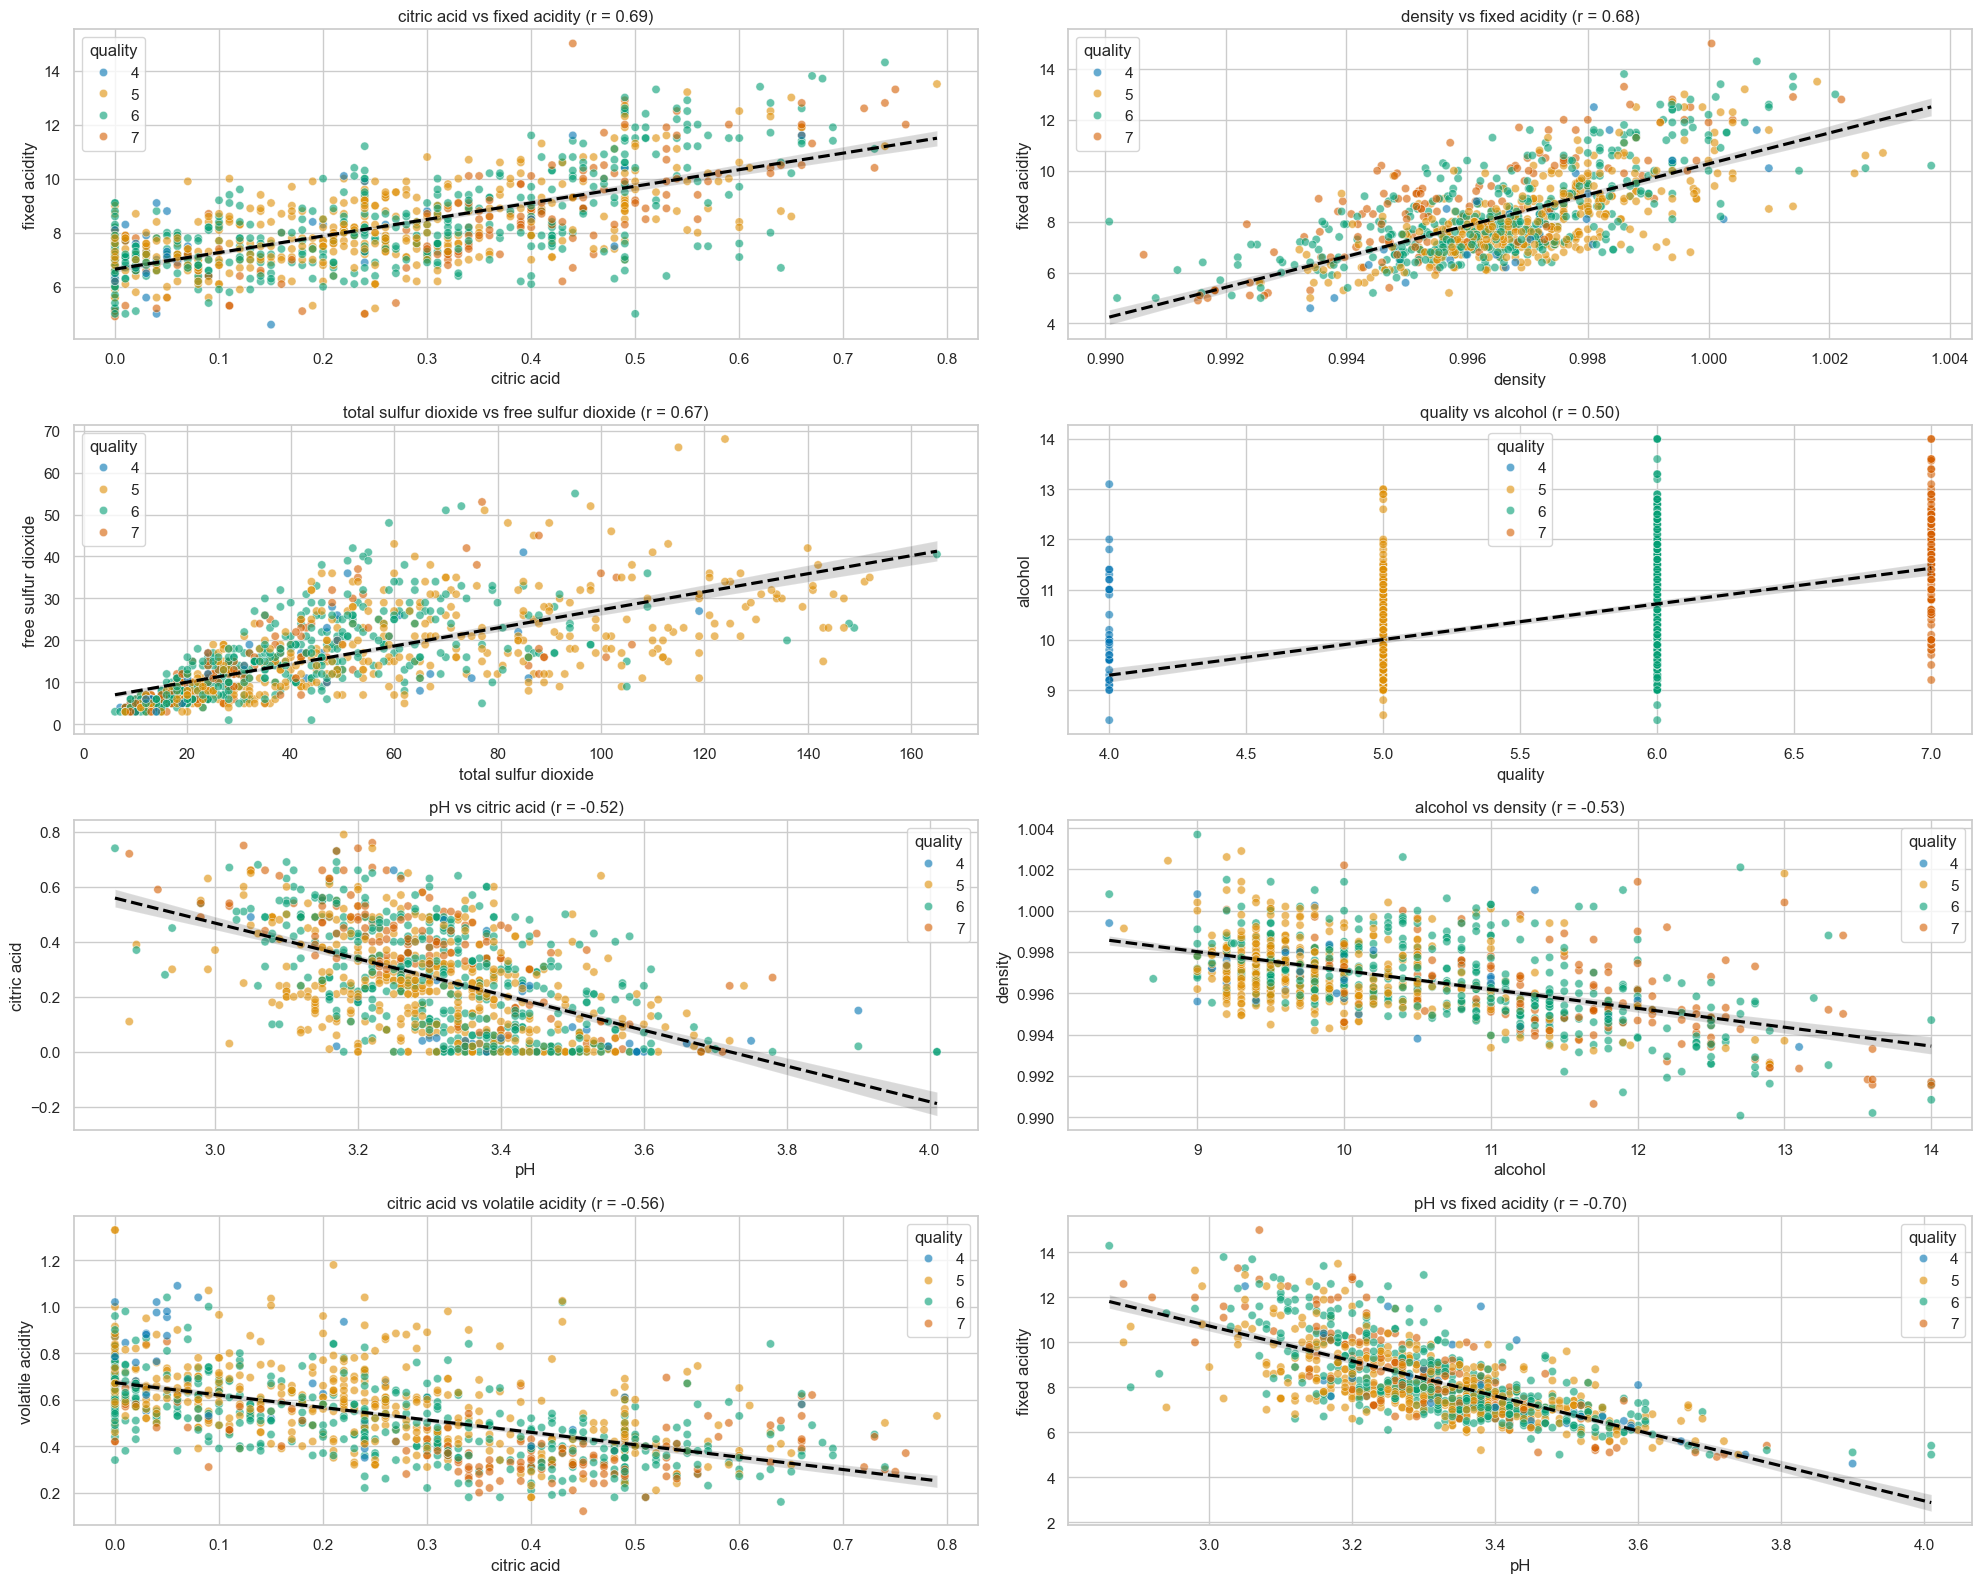

In [19]:
sns.set_theme(style="whitegrid")

cols = 2
rows = math.ceil(len(strong_pairs) / cols)

plt.figure(figsize=(20, 4 * rows))

for i, (_, row) in enumerate(strong_pairs.iterrows(), 1):
    v1 = row["var_1"]
    v2 = row["var_2"]
    r  = row["r"]

    plt.subplot(rows, cols, i)

    # Colored scatter
    sns.scatterplot(
        data=df_clean,
        palette = sns.color_palette("colorblind"),
        x=v1,
        y=v2,
        hue="quality",   # or "quality_cat" or "quality"
        alpha=0.6
    )

    # Regression line (no scatter)
    sns.regplot(
        data=df_clean,
        x=v1,
        y=v2,
        scatter=False,
        line_kws={"linestyle": "--", "color": "black"}
    )

    plt.title(f"{v1} vs {v2} (r = {r:.2f})")
    plt.xlabel(v1)
    plt.ylabel(v2)

plt.tight_layout()
plt.show()

<Axes: xlabel='alcohol', ylabel='Density'>

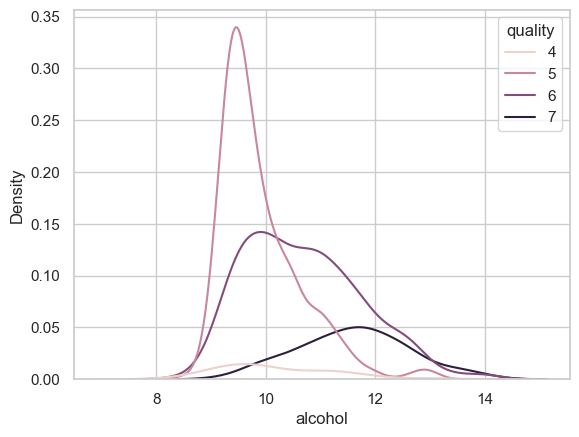

In [20]:
sns.kdeplot(data = df_clean, x='alcohol', hue = 'quality')

<Axes: xlabel='volatile acidity', ylabel='Density'>

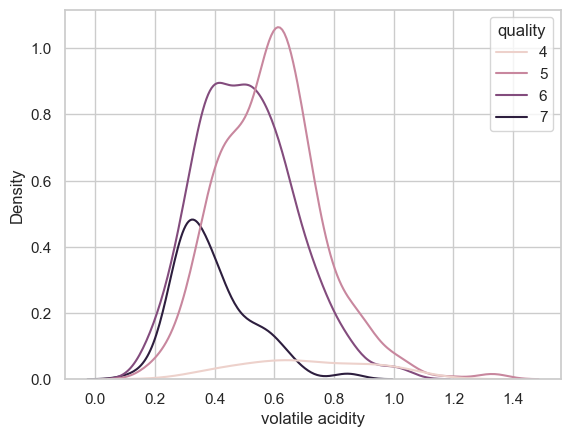

In [21]:
sns.kdeplot(data = df_clean, x='volatile acidity', hue = 'quality')

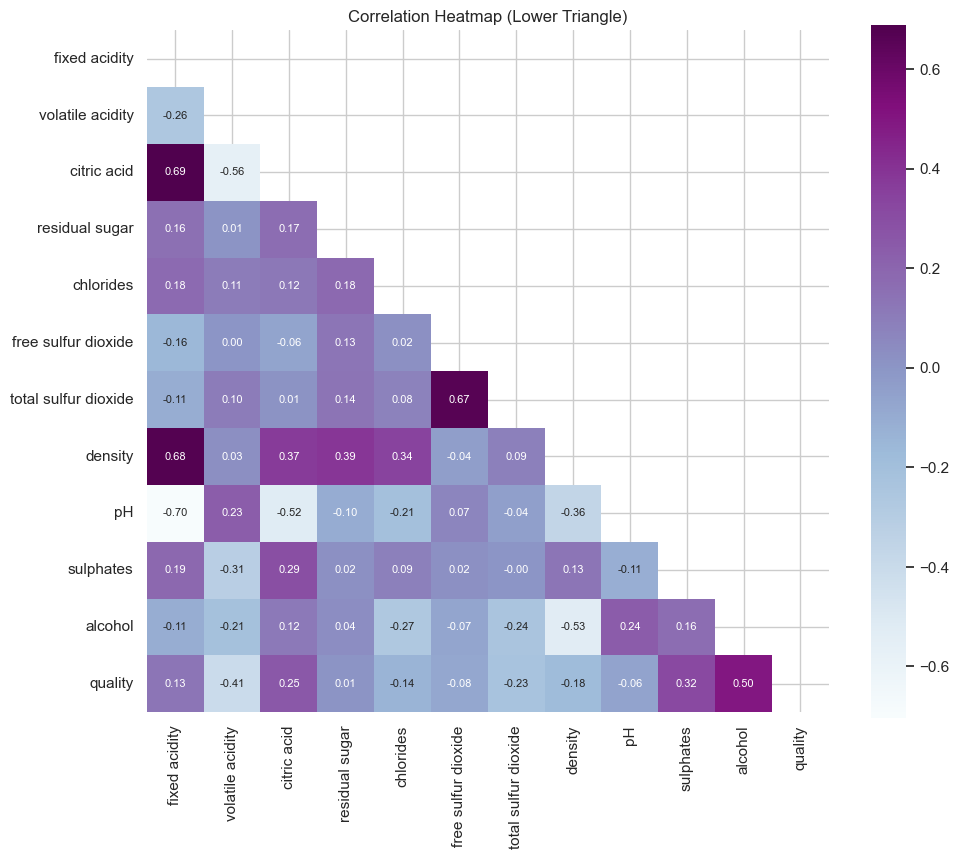

In [22]:
plt.figure(figsize=(11,9))

corr = df_clean.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    cmap = 'BuPu',
    center=0,
    square=True,
    annot=True,
    fmt=".2f",
    annot_kws={"size":8}
)

plt.title("Correlation Heatmap (Lower Triangle)")
plt.show()


In [23]:
to_be_discarded = ["pH", "free sulfur dioxide", "residual sugar", "fixed acidity"]

In [24]:
num_cols = [
    "volatile acidity",
    "citric acid",
    "chlorides",
    "total sulfur dioxide",
    "density",
    "sulphates",
    "alcohol"
]

In [25]:
df_ml = df_clean.drop(columns = to_be_discarded).copy()
df_ml

,volatile acidity,citric acid,chlorides,total sulfur dioxide,density,sulphates,alcohol,quality
0,0.700,0.00,0.076,34.0,0.99780,0.56,9.4,5
1,0.880,0.00,0.098,67.0,0.99680,0.68,9.8,5
2,0.760,0.04,0.092,54.0,0.99700,0.65,9.8,5
3,0.280,0.56,0.075,60.0,0.99800,0.58,9.8,6
4,0.660,0.00,0.075,40.0,0.99780,0.56,9.4,5
...,...,...,...,...,...,...,...,...
1013,0.510,0.13,0.076,40.0,0.99574,0.75,11.0,6
1014,0.620,0.08,0.068,38.0,0.99651,0.82,9.5,6
1015,0.600,0.08,0.090,44.0,0.99490,0.58,10.5,5
1016,0.550,0.10,0.062,51.0,0.99512,0.76,11.2,6


In [26]:
# Corrected code with axis parameter added to drop()
X = df_ml.drop("quality", axis=1)  # axis=1 specifies that we're dropping a column
y = df_ml["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [27]:
dt_classifier = DecisionTreeClassifier(criterion='gini', max_depth=3)  # Limit depth for clarity
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [28]:
y_train_pred = dt_classifier.predict(X_train)
y_test_pred  = dt_classifier.predict(X_test)

In [29]:
from sklearn.metrics import confusion_matrix

cm_train = confusion_matrix(y_train, y_train_pred)
cm_test  = confusion_matrix(y_test, y_test_pred)

print("Train Confusion Matrix:\n", cm_train)
print("\nTest Confusion Matrix:\n", cm_test)

Train Confusion Matrix:
 [[  0  16  10   0]
 [  0 197  93   6]
 [  0  56 193  33]
 [  0   3  38  52]]

Test Confusion Matrix:
 [[ 0  8  3  0]
 [ 0 78 46  3]
 [ 0 39 68 15]
 [ 0  2 21 17]]


In [30]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy  = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:  {test_accuracy:.4f}")

Train Accuracy: 0.6341
Test Accuracy:  0.5433


In [31]:
from sklearn.metrics import classification_report

print("TRAIN REPORT")
print(classification_report(y_train, y_train_pred))  # Added closing parenthesis here

print("TEST REPORT")
print(classification_report(y_test, y_test_pred))  # Added closing parenthesis here

TRAIN REPORT
              precision    recall  f1-score   support

           4       0.00      0.00      0.00        26
           5       0.72      0.67      0.69       296
           6       0.58      0.68      0.63       282
           7       0.57      0.56      0.57        93

    accuracy                           0.63       697
   macro avg       0.47      0.48      0.47       697
weighted avg       0.62      0.63      0.62       697

TEST REPORT
              precision    recall  f1-score   support

           4       0.00      0.00      0.00        11
           5       0.61      0.61      0.61       127
           6       0.49      0.56      0.52       122
           7       0.49      0.42      0.45        40

    accuracy                           0.54       300
   macro avg       0.40      0.40      0.40       300
weighted avg       0.53      0.54      0.53       300



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\m

In [32]:
accuracy_dt = metrics.accuracy_score(y_test, y_test_pred)
print(f"Decision Tree Accuracy: {accuracy_dt:.2f}")

Decision Tree Accuracy: 0.54


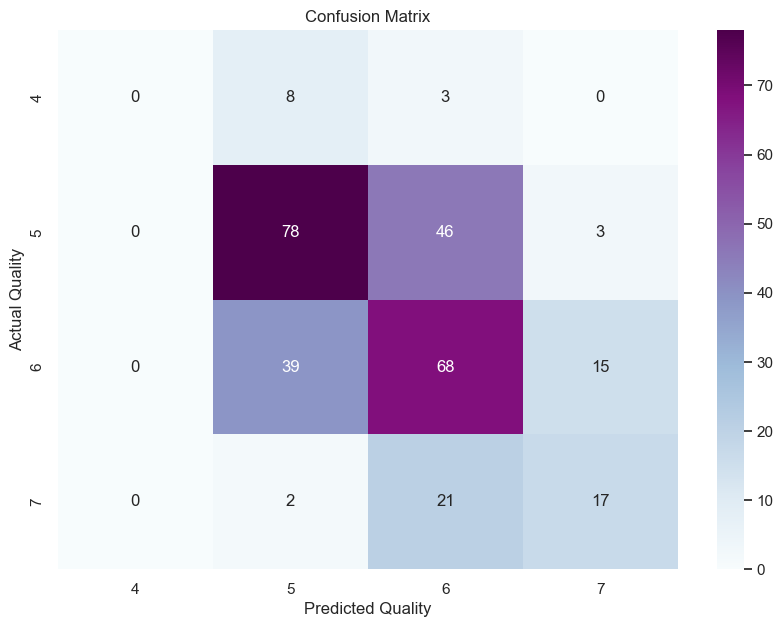

In [33]:
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.title('Confusion Matrix')
plt.show()

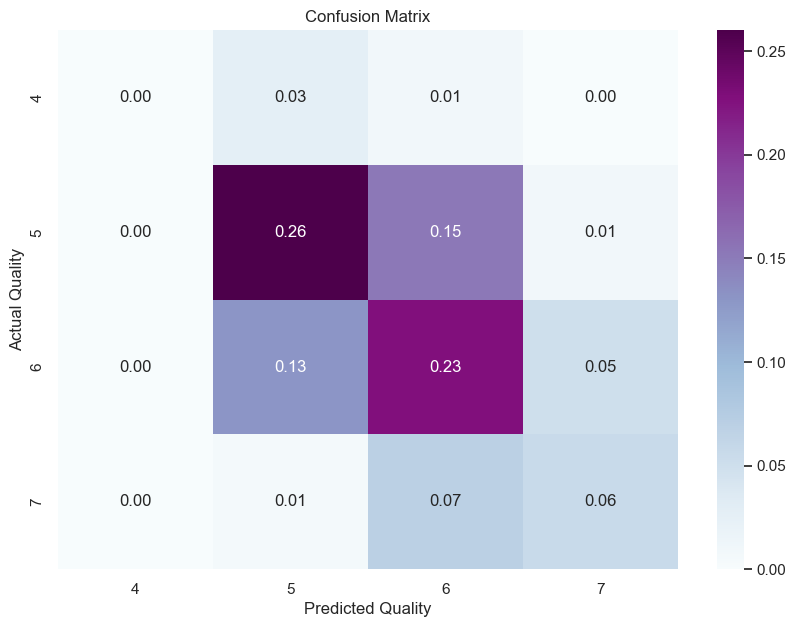

In [34]:
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_test_pred)/len(y_test)
sns.heatmap(cm, annot=True, fmt='.2f', cmap='BuPu',  # Changed 'd' to '.2f' to format floats
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.title('Confusion Matrix')
plt.show()

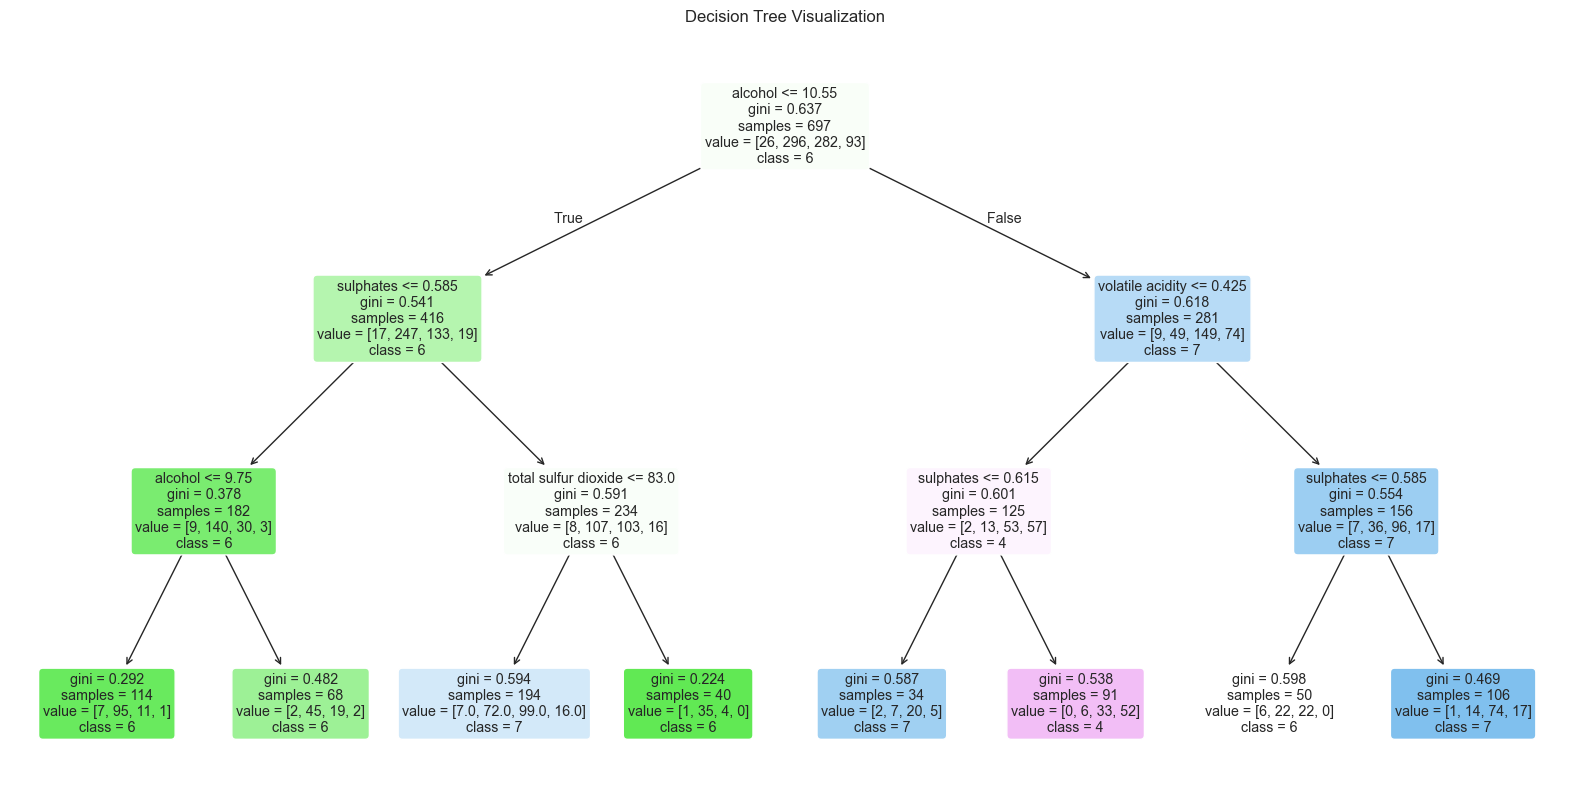

In [35]:
plt.figure(figsize=(20, 10))
class_names = [str(class_val) for class_val in y.unique()]
plot_tree(dt_classifier, filled=True, feature_names=X.columns, class_names=class_names, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

## Grid Search

In [36]:
param_dist = {
    "max_depth": [2, 3],
    "min_samples_split": [6,8,10],
    "min_samples_leaf": [2,5,7],
    "max_features": [2,4,6],
    "criterion": ["gini", "entropy"]
}

In [37]:
from sklearn.model_selection import RandomizedSearchCV

clf = DecisionTreeClassifier()
clf_search = RandomizedSearchCV(clf, param_distributions=param_dist, n_iter=10, cv=5, random_state=42, n_jobs=1)
clf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [2, 3],
                                        'max_features': [2, 4, 6],
                                        'min_samples_leaf': [2, 5, 7],
                                        'min_samples_split': [6, 8, 10]},
                   random_state=42)

In [38]:
clf_search.best_params_

{'min_samples_split': 6,
 'min_samples_leaf': 2,
 'max_features': 6,
 'max_depth': 3,
 'criterion': 'gini'}

In [39]:
clf_search.best_score_

np.float64(0.5824254881808839)

In [40]:
clf_search.score(X_train, y_train), clf_search.score(X_test, y_test)

(0.6327116212338594, 0.5466666666666666)

In [41]:
best_clf = clf_search.best_estimator_

y_pred = best_clf.predict(X_test)

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[ 0,  8,  3,  0],
       [ 0, 79, 46,  2],
       [ 0, 40, 69, 13],
       [ 0,  3, 21, 16]])

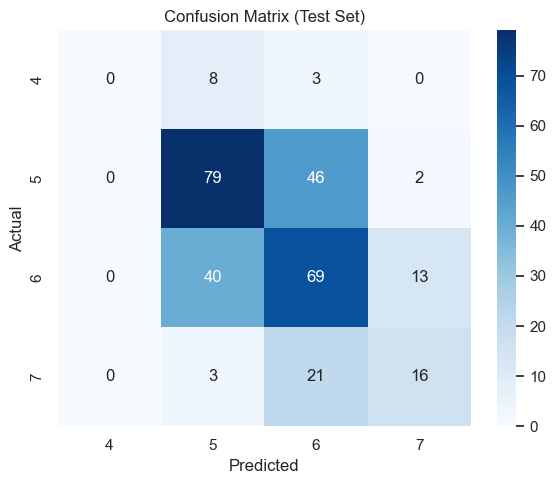

In [43]:
plt.figure(figsize=(6,5))

quality_labels = [4, 5, 6, 7]

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=quality_labels,
    yticklabels=quality_labels
)

plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


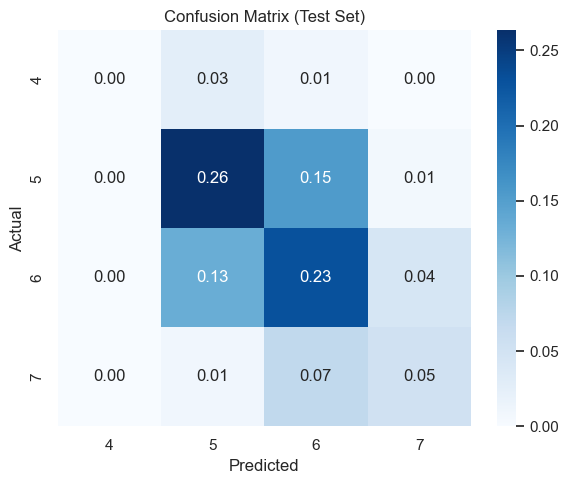

In [44]:
cm = confusion_matrix(y_test, y_pred)/len(y_test)
plt.figure(figsize=(6,5))

quality_labels = [4, 5, 6, 7]

sns.heatmap(
    cm,
    annot=True,
    fmt="0.2f",
    cmap="Blues",
    xticklabels=quality_labels,
    yticklabels=quality_labels
)

plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

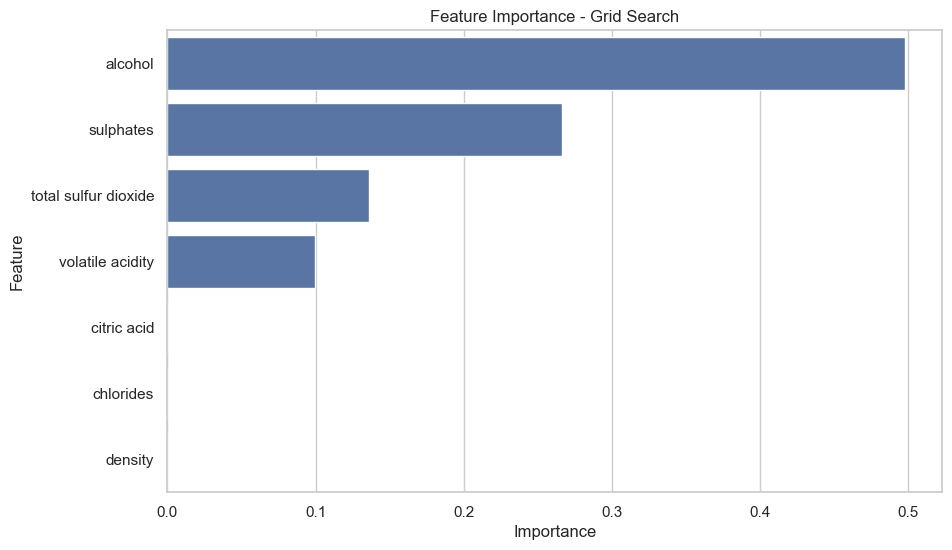

In [45]:
grs_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=grs_df, x='Importance', y='Feature')
plt.title('Feature Importance - Grid Search')
plt.show()

## Without Quality Level 4

In [46]:
df_ml_clean = df_ml[df_ml["quality"] != 4].copy()
df_ml_clean

,volatile acidity,citric acid,chlorides,total sulfur dioxide,density,sulphates,alcohol,quality
0,0.700,0.00,0.076,34.0,0.99780,0.56,9.4,5
1,0.880,0.00,0.098,67.0,0.99680,0.68,9.8,5
2,0.760,0.04,0.092,54.0,0.99700,0.65,9.8,5
3,0.280,0.56,0.075,60.0,0.99800,0.58,9.8,6
4,0.660,0.00,0.075,40.0,0.99780,0.56,9.4,5
...,...,...,...,...,...,...,...,...
1013,0.510,0.13,0.076,40.0,0.99574,0.75,11.0,6
1014,0.620,0.08,0.068,38.0,0.99651,0.82,9.5,6
1015,0.600,0.08,0.090,44.0,0.99490,0.58,10.5,5
1016,0.550,0.10,0.062,51.0,0.99512,0.76,11.2,6


In [47]:
X_clean = df_ml_clean.drop("quality", axis=1)  # axis=1 specifies that we're dropping a column
y_clean = df_ml_clean["quality"]

# Make sure X_clean and y_clean have the same number of samples
# This ensures they are derived from the same DataFrame without any filtering issues

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean,
    test_size=0.3,
    random_state=42,
    stratify=y_clean  # Changed from y to y_clean to match the target variable name
)

In [48]:
dt_classifier = DecisionTreeClassifier(criterion='gini', max_depth=3)  # Limit depth for clarity
dt_classifier.fit(X_train_clean, y_train_clean)

DecisionTreeClassifier(max_depth=3)

In [49]:
y_pred_test_clean = dt_classifier.predict(X_test_clean)
y_pred_train_clean = dt_classifier.predict(X_train_clean)

In [50]:
train_accuracy = accuracy_score(y_train_clean, y_pred_train_clean)
test_accuracy  = accuracy_score(y_test_clean, y_pred_test_clean)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:  {test_accuracy:.4f}")

Train Accuracy: 0.6518
Test Accuracy:  0.5833


In [51]:
print("Decision Tree Classification Report:")
print(metrics.classification_report(y_test_clean, y_pred_test_clean, zero_division=0))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           5       0.69      0.57      0.63       127
           6       0.52      0.67      0.58       121
           7       0.56      0.35      0.43        40

    accuracy                           0.58       288
   macro avg       0.59      0.53      0.55       288
weighted avg       0.60      0.58      0.58       288



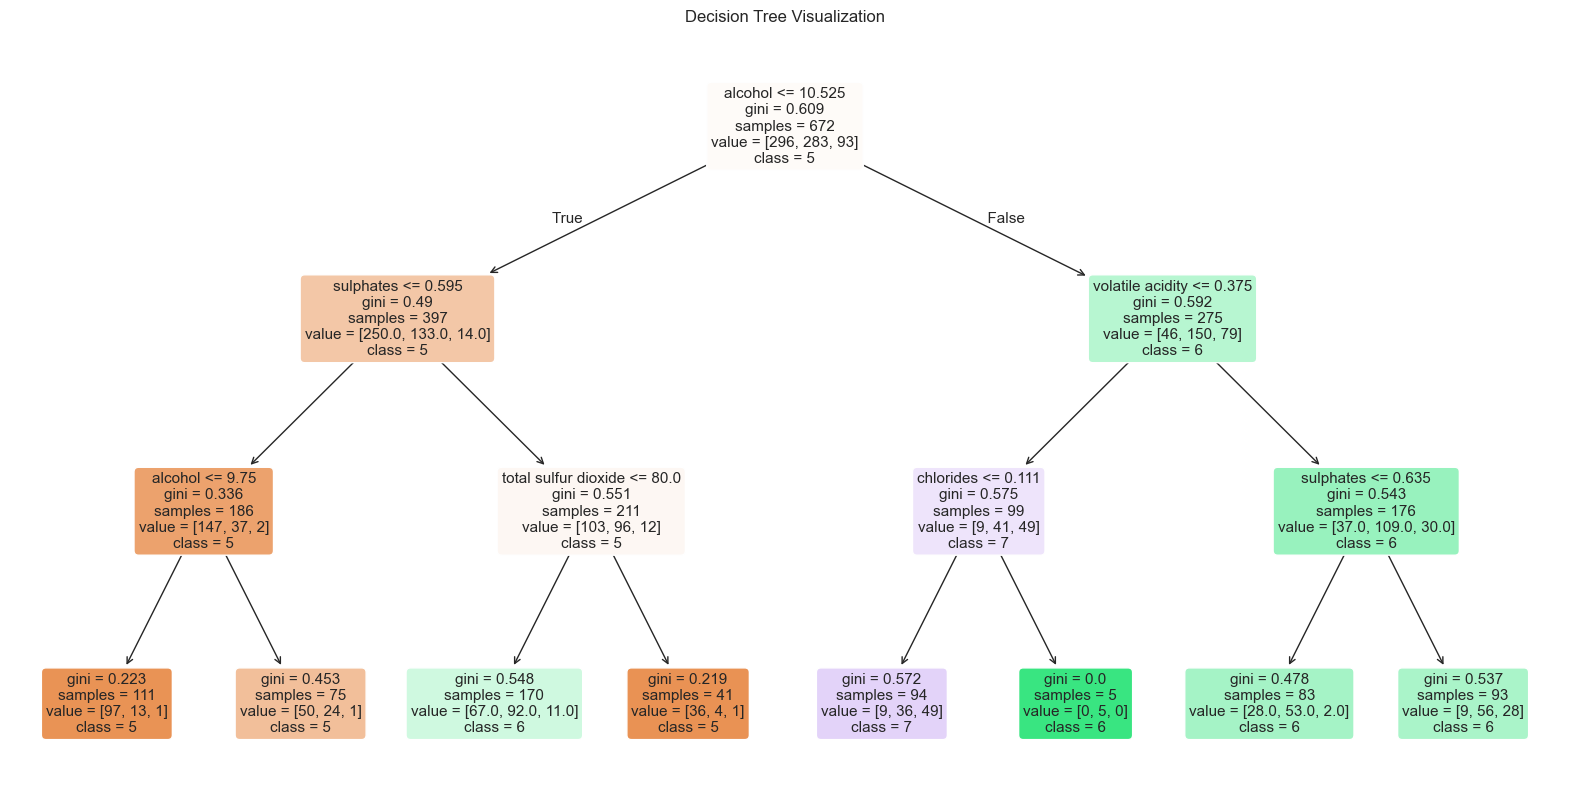

In [52]:
plt.figure(figsize=(20, 10))
class_names = [str(class_val) for class_val in y_clean.unique()]
plot_tree(dt_classifier, filled=True, feature_names=X_clean.columns, class_names=class_names, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

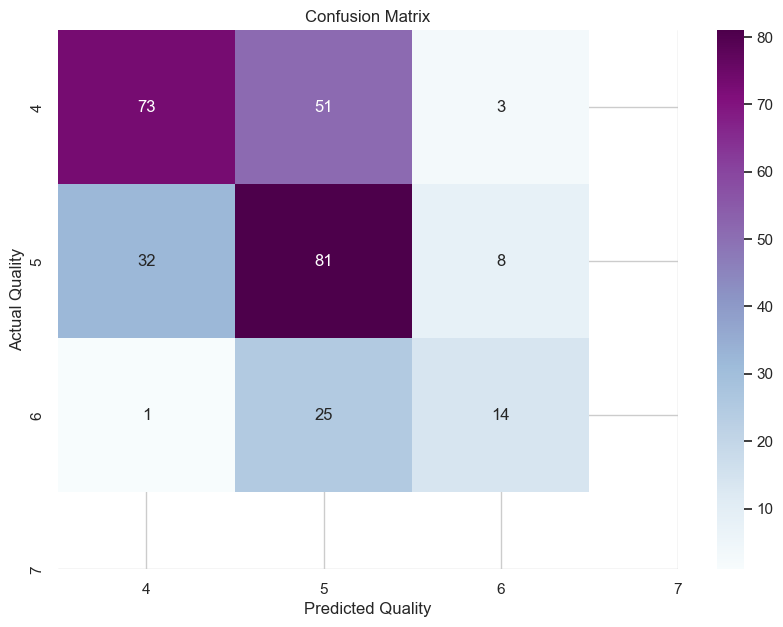

In [53]:
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test_clean, y_pred_test_clean)
sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.title('Confusion Matrix')
plt.show()

## Naive - Bayes

In [54]:
from sklearn.naive_bayes import GaussianNB
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)

y_pred_nb = nb_classifier.predict(X_test)

print("Naive Bayes Classification Report:")
print(metrics.classification_report(y_test, y_pred_nb, zero_division=0))
accuracy_nb = metrics.accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {accuracy_nb:.2f}")

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           4       0.33      0.09      0.14        11
           5       0.65      0.83      0.73       127
           6       0.62      0.43      0.51       122
           7       0.53      0.68      0.59        40

    accuracy                           0.62       300
   macro avg       0.53      0.51      0.49       300
weighted avg       0.61      0.62      0.60       300

Naive Bayes Accuracy: 0.62


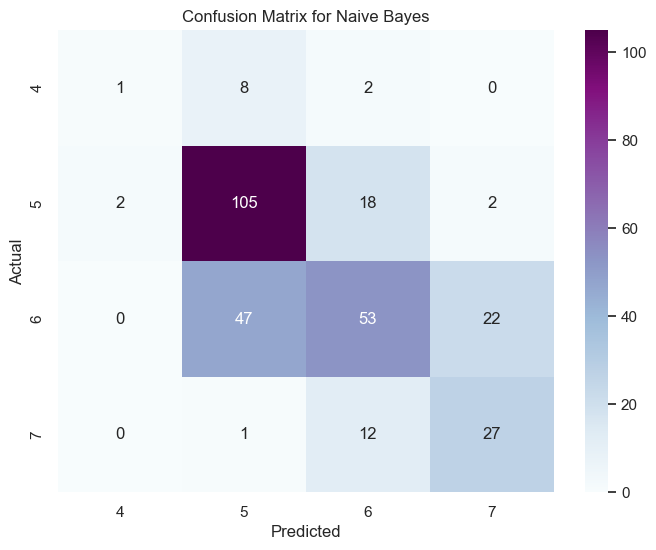

In [55]:
confusion_mtx = metrics.confusion_matrix(y_test, y_pred_nb)
labels = sorted(y.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_mtx, 
    annot=True, 
    fmt='d', 
    cmap='BuPu', 
    xticklabels=labels, 
    yticklabels=labels
)

plt.title("Confusion Matrix for Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Random Forest

In [56]:
param_dist_rf = {
    "n_estimators": [10, 30, 50, 100, 200],
    "max_depth": [2, 3],
    "min_samples_split": [6, 8, 10],
    "min_samples_leaf": [2, 5, 7],
    "criterion": ["gini", "entropy"],
    "max_features": ["sqrt", "log2", None, 5]
}


In [57]:
# Import necessary libraries if not already imported
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# First, create the RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Then, use RandomizedSearchCV for hyperparameter tuning
rf_clf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,  # Your parameter distribution dictionary
    n_iter=10,
    cv=5,
    random_state=42,
)

# Now fit the model
rf_clf.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [2, 3],
                                        'max_features': ['sqrt', 'log2', None,
                                                         5],
                                        'min_samples_leaf': [2, 5, 7],
                                        'min_samples_split': [6, 8, 10],
                                        'n_estimators': [10, 30, 50, 100, 200]},
                   random_state=42)

In [58]:
y_pred_rf = rf_clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Accuracy: 0.5833
              precision    recall  f1-score   support

           4       0.00      0.00      0.00        11
           5       0.64      0.65      0.64       127
           6       0.52      0.66      0.58       122
           7       0.68      0.33      0.44        40

    accuracy                           0.58       300
   macro avg       0.46      0.41      0.42       300
weighted avg       0.58      0.58      0.57       300



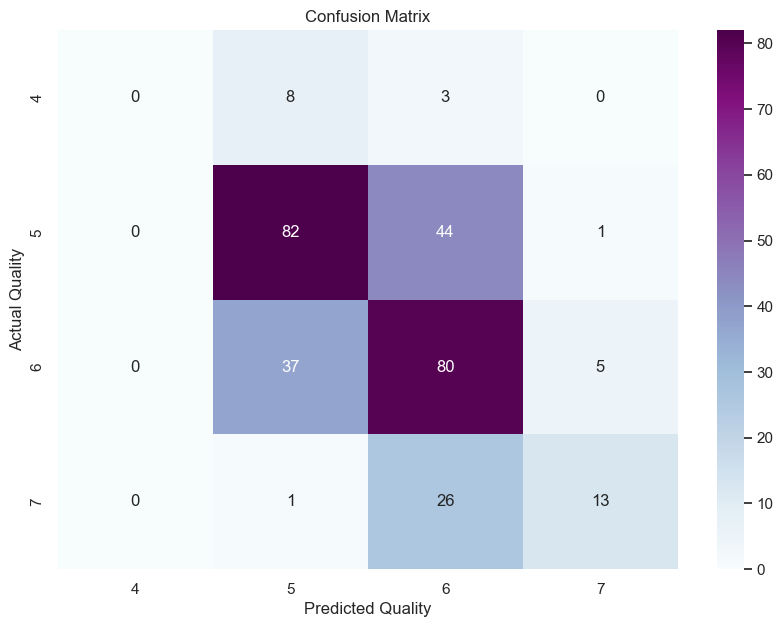

In [59]:
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.title('Confusion Matrix')
plt.show()

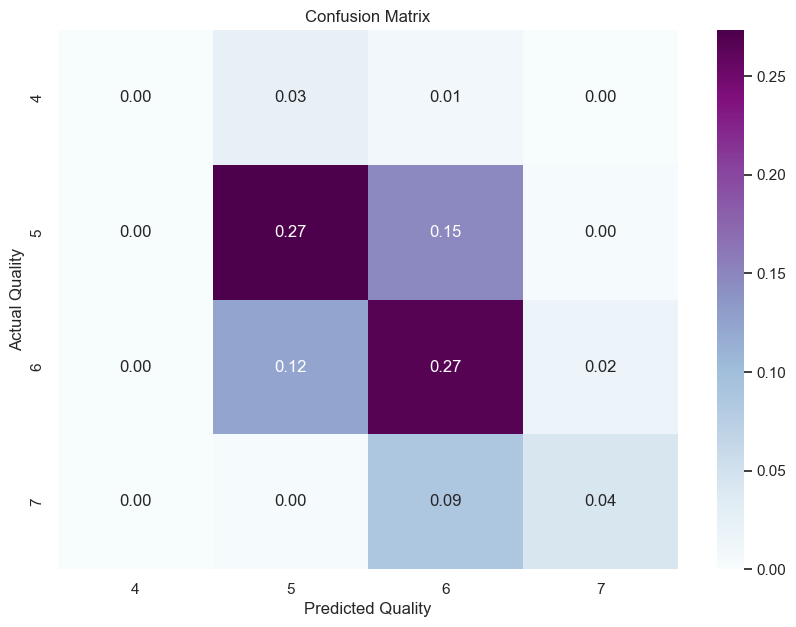

In [60]:
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred_rf)/len(y_test)
sns.heatmap(cm, annot=True, fmt='0.2f', cmap='BuPu', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.title('Confusion Matrix')
plt.show()

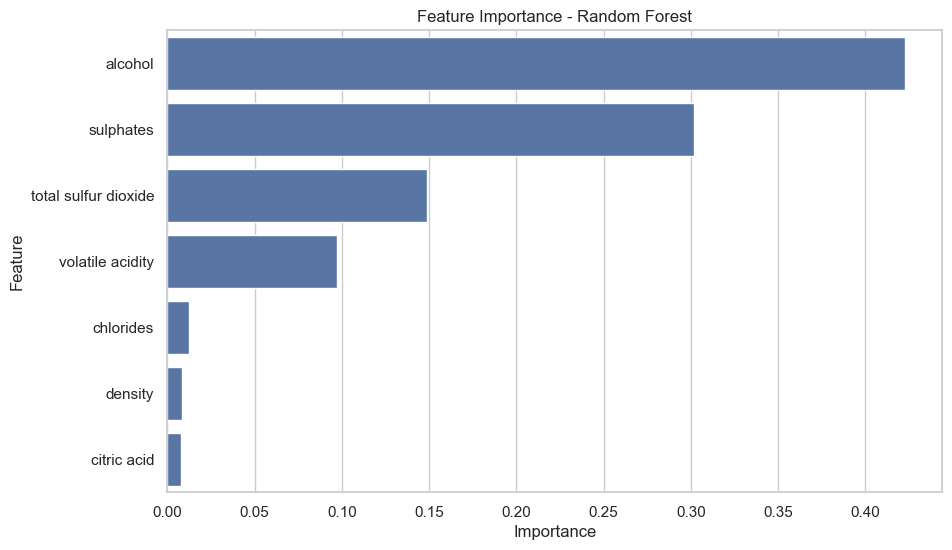

In [61]:
# Access feature_importances_ from the best estimator
fi_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_clf.best_estimator_.feature_importances_  # Access through best_estimator_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, x='Importance', y='Feature')
plt.title('Feature Importance - Random Forest')
plt.show()

In [62]:
rf_clf.best_params_

{'n_estimators': 50,
 'min_samples_split': 8,
 'min_samples_leaf': 5,
 'max_features': None,
 'max_depth': 3,
 'criterion': 'gini'}

## Gradient Boosting

In [63]:
param_dist_gb = {
    'n_estimators' : [10, 30, 50, 100, 200],
    "max_depth": [2, 3],
    "min_samples_split": [4,6,8,10],
    "min_samples_leaf": [5, 7, 9],
    "criterion": ['friedman_mse', 'squared_error'],
    'max_features' : ['sqrt', 3, 5, 6],
    'learning_rate' : np.logspace(-3, 0, 100)
}

In [64]:
gb_model = GradientBoostingClassifier()

gb_clf = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist_gb,  # Your parameter distribution dictionary
    n_iter=10,
    cv=5,
    random_state=42,
)
gb_clf.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(),
                   param_distributions={'criterion': ['friedman_mse',
                                                      'squared_error'],
                                        'learning_rate': array([0.001     , 0.00107227, 0.00114976, 0.00123285, 0.00132194,
       0.00141747, 0.00151991, 0.00162975, 0.00174753, 0.00187382,
       0.00200923, 0.00215443, 0.00231013, 0.00247708, 0.00265609,
       0.00284804, 0.00305386, 0.00327455, 0.003...
       0.26560878, 0.28480359, 0.30538555, 0.32745492, 0.35111917,
       0.37649358, 0.40370173, 0.43287613, 0.46415888, 0.49770236,
       0.53366992, 0.57223677, 0.61359073, 0.65793322, 0.70548023,
       0.75646333, 0.81113083, 0.869749  , 0.93260335, 1.        ]),
                                        'max_depth': [2, 3],
                                        'max_features': ['sqrt', 3, 5, 6],
                                        'min_samples_leaf': [5, 7, 9],
                                        'min_samples_split': [4, 6, 8, 10],
                                        'n_estimators': [10, 30, 50, 100, 200]},
                   random_state=42)

In [65]:
y_pred_gb = gb_clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(classification_report(y_test, y_pred_gb, zero_division=0))

Accuracy: 0.5700
              precision    recall  f1-score   support

           4       0.00      0.00      0.00        11
           5       0.63      0.72      0.67       127
           6       0.51      0.65      0.57       122
           7       0.00      0.00      0.00        40

    accuracy                           0.57       300
   macro avg       0.29      0.34      0.31       300
weighted avg       0.48      0.57      0.52       300



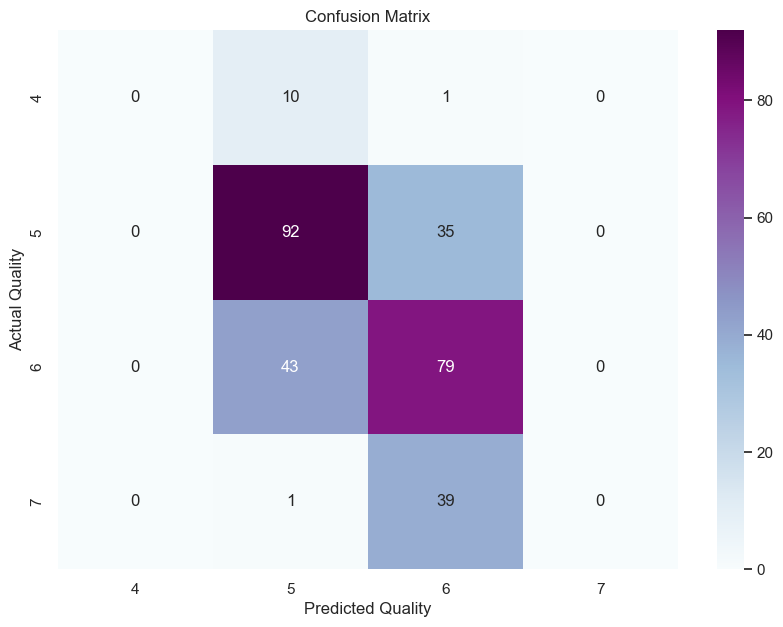

In [66]:
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.title('Confusion Matrix')
plt.show()

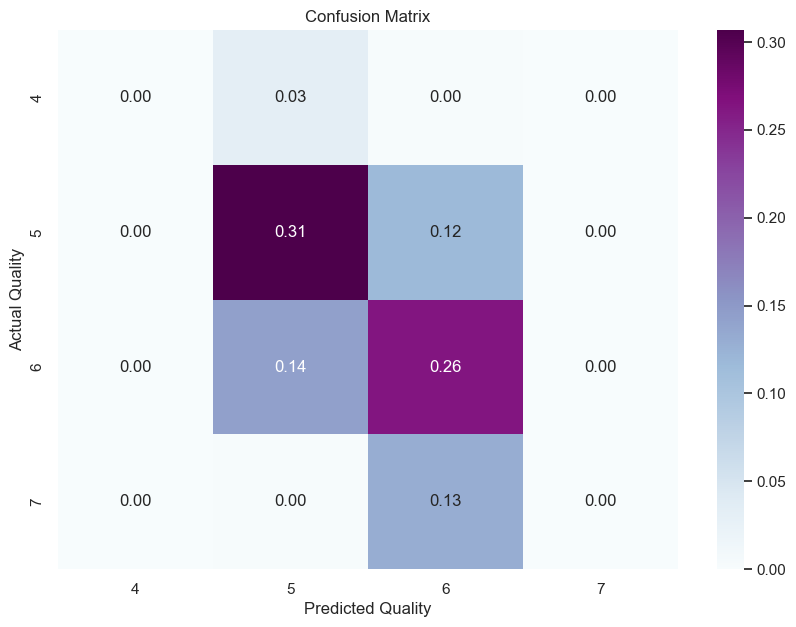

In [67]:
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred_gb)/len(y_test)
sns.heatmap(cm, annot=True, fmt='0.2f', cmap='BuPu', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.title('Confusion Matrix')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_42420\1650194657.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_gb, x='Importance', y='Feature', palette='magma')


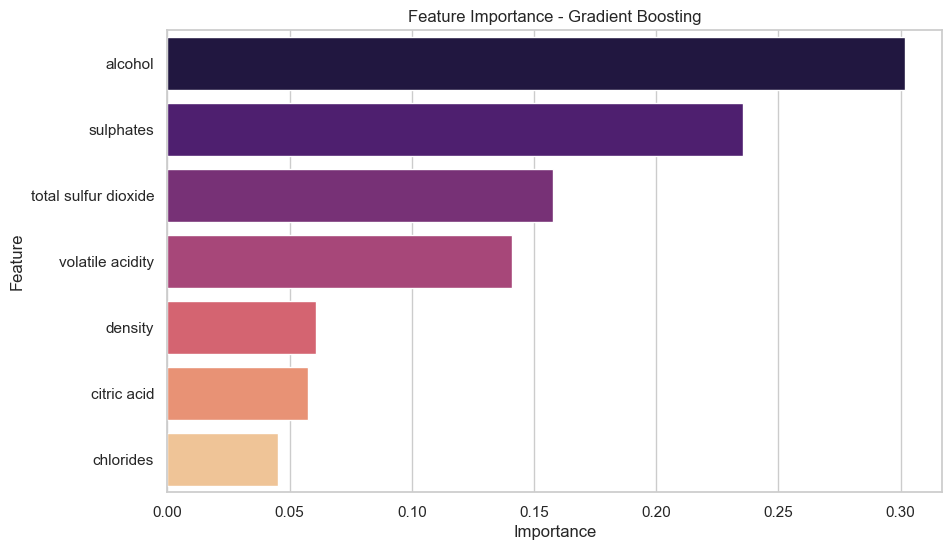

In [68]:
fi_gb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_clf.best_estimator_.feature_importances_  # Changed from best_model to best_estimator_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_gb, x='Importance', y='Feature', palette='magma')
plt.title('Feature Importance - Gradient Boosting')
plt.show()

In [69]:
gb_clf.best_score_

np.float64(0.5952723535457348)

In [70]:
gb_clf.score(X_train, y_train), gb_clf.score(X_test, y_test)

(0.6542324246771879, 0.57)